In [1]:
library(tidyverse)
library(lubridate)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




# Metadata

In [2]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

### remove 100 and 24
mdf = mdf %>% filter(!Record_ID %in% c("24"))

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% 
    mutate(agvhd = case_when(
            !is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD+",
            is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD-",
            timepoint == "HD" ~ "Healthy Donor")) %>%
    mutate(agvhd = factor(agvhd, levels = c("Healthy Donor","aGVHD-","aGVHD+")))

### IPA

png 
  2

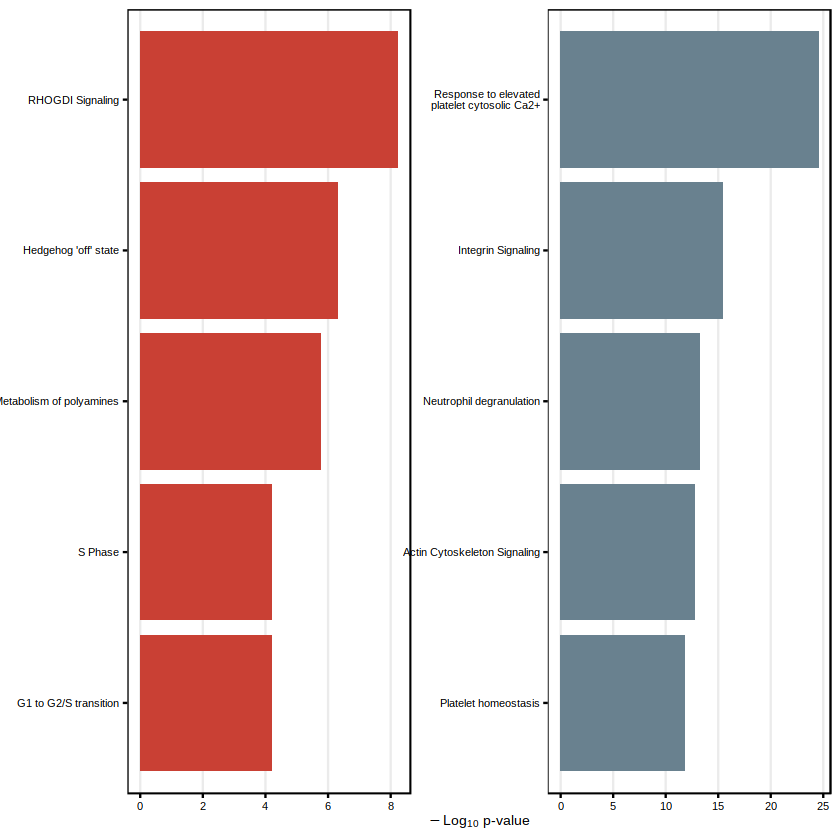

In [ ]:
N = 5

# df = read.delim("./outputs/E_agvhdvsall.ipaOUT.txt",skip = 2)
df = read.delim("/agvhd_ipa_out.txt",skip = 2)

colnames(df) <- c("pathway","logpval","ratio","zscore","genes","X")


df <- df %>% 
        filter(abs(zscore) > 0.5) %>% 
    mutate(group=ifelse(zscore >0,"aGVHD+","aGVHD-")) %>% 
    # mutate(group=ifelse(zscore >0,"neg","pos")) %>% 
    filter(!is.na(group)) %>%
    arrange(desc(logpval))

df_1 <- df %>% filter(group == 'aGVHD+') %>% head(N)
df_2 <- df %>% filter(group == "aGVHD-") %>% head(N) #%>% arrange(logpval)

df <- rbind(df_1,df_2)

# df = df %>% mutate(pathway = ifelse(grepl("Cytokine Storm",pathway),"Pathogen Induced Cytokine\nStorm Signaling",pathway))
# df = df %>% mutate(pathway = ifelse(grepl("Class A/1",pathway),"Class A/1 (Rhodopsin-like receptors)",pathway))
# df = df %>% mutate(pathway = ifelse(grepl("IL-12",pathway),"Macrophage IL-12\nSignaling and Production",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Response to elevated",pathway),"Response to elevated\nplatelet cytosolic Ca2+",pathway))
df = df %>% mutate(pathway = ifelse(grepl("alpha/beta",pathway),"Interferon alpha/beta\nsignaling",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Interferon gamma",pathway),"Interferon gamma\nsignaling",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Neutrophil degran",pathway),"Neutrophil degranulation",pathway))

df = df %>% mutate(pathway = ifelse(grepl("Mitotic G1",pathway),"G1 to G2/S transition",pathway))




order <- rev(df$pathway)


ipa_plt <- df %>% 
        mutate(group = factor(group, levels = c("aGVHD+","aGVHD-"))) %>%
        # mutate(group = factor(group, levels = c("aGVHD+"))) %>%
        filter(!is.na(group)) %>%

        mutate(pathway = factor(pathway, levels = order)) %>%
        ggplot(aes(x=logpval, y=pathway, fill = group))+
        geom_bar(stat="identity")+
        theme_cfrna_print()+
        facet_wrap(~group, scales = "free", ncol = 2)+
        labs(x=bquote(-Log[10]*" p-value"))+

        theme_cfrna_print() +
        theme(
                axis.title.y = element_blank(),
                legend.position = "none",
                panel.grid.minor.y = element_blank(),       # Remove minor gridlines
                strip.background = element_blank(),
                strip.text = element_blank(),
                panel.grid.minor.x = element_blank(),
                panel.grid.major.y = element_blank()
        )+
        scale_fill_manual(values = COLORs)

print(ipa_plt)
WIDTH= 4
HEIGHT= 1.45

pdf(file="figures/aGVHD_E-ipa.top6.pdf",
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
        fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
ipa_plt
dev.off()

In [ ]:

## Get Results
dds = readRDS("./outputs/DESEQ2_agvhdE.LONG.rds")
res <- results(dds) 

res_df <- res %>% data.frame()
res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

res_df %>% write.csv("./outputs/hsct_cfrna_DataS2.csv",quote=FALSE)


In [ ]:
res_df %>% filter(grepl("^HLA",gene_name)) %>% filter(padj < 0.1)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000204525.17,3097.083,0.005409569,0.001547181,3.496403,0.0004715758,0.06484829,HLA-C,protein_coding
ENSG00000204592.9,6097.044,0.005471662,0.001728140,3.166215,0.0015443636,0.08312731,HLA-E,protein_coding
ENSG00000206503.13,2622.310,0.005977573,0.001677921,3.562487,0.0003673579,0.06484829,HLA-A,protein_coding
ENSG00000234745.13,4980.892,0.005087824,0.001659548,3.065790,0.0021709584,0.08856822,HLA-B,protein_coding


In [ ]:
GENEs = c("HLA-A","HLA-B","HLA-C","HLA-E")

GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_daa)

### Combine counts with metadata
cnt_df = merge(mdf_agvhd_daa %>% select(sample_id, date_agvhd, rel_agvhd, timepoint, Record_ID), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_agvhd","rel_agvhd","timepoint", "Record_ID"), variable.name = "gene_id",value.name = "counts")
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs)) 

In [ ]:
for (G in GENEs){
    cat(G,"\n")
    cnt_df_G = cnt_df %>% filter(gene_name == G)
    cor.test(cnt_df_G$rel_agvhd, cnt_df_G$counts) %>% print()
    cat("-------------\n")
}

HLA-A 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 2.7653, df = 69, p-value = 0.007291
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.08911951 0.51146936
sample estimates:
     cor 
0.315856 

-------------
HLA-B 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 2.2821, df = 69, p-value = 0.02557
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.03370087 0.46922395
sample estimates:
      cor 
0.2649216 

-------------
HLA-C 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 3.1793, df = 69, p-value = 0.002211
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1354475 0.5452848
sample estimates:
      cor 
0.3574555 

-------------
HLA-E 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 3.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”


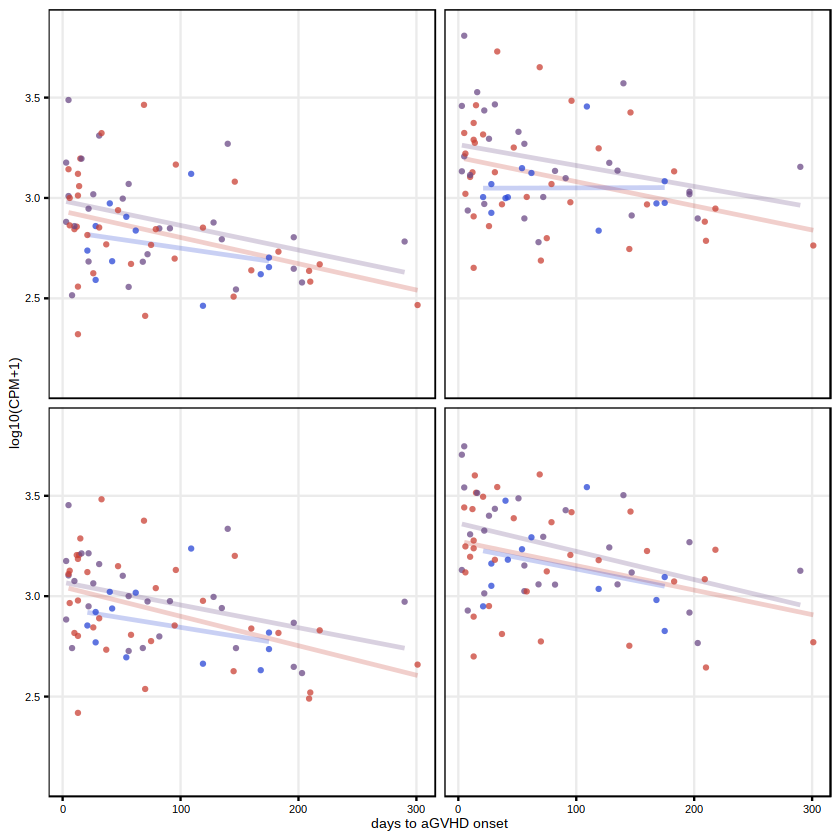

In [ ]:
COLS = c("E" = COLORs[["aGVHD+"]], "1M" = "#6B4A86", "2M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_agvhd, y=log10(counts+1), color = timepoint))+
    geom_line(stat="smooth",method = "lm",
            # color = "black",
            size = 1,alpha = 0.25)+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=2)+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "days to aGVHD onset")+
    scale_color_manual(values = COLS )+
    theme(
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )

### Save
WIDTH = 2.55
HEIGHT = 2.5

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”


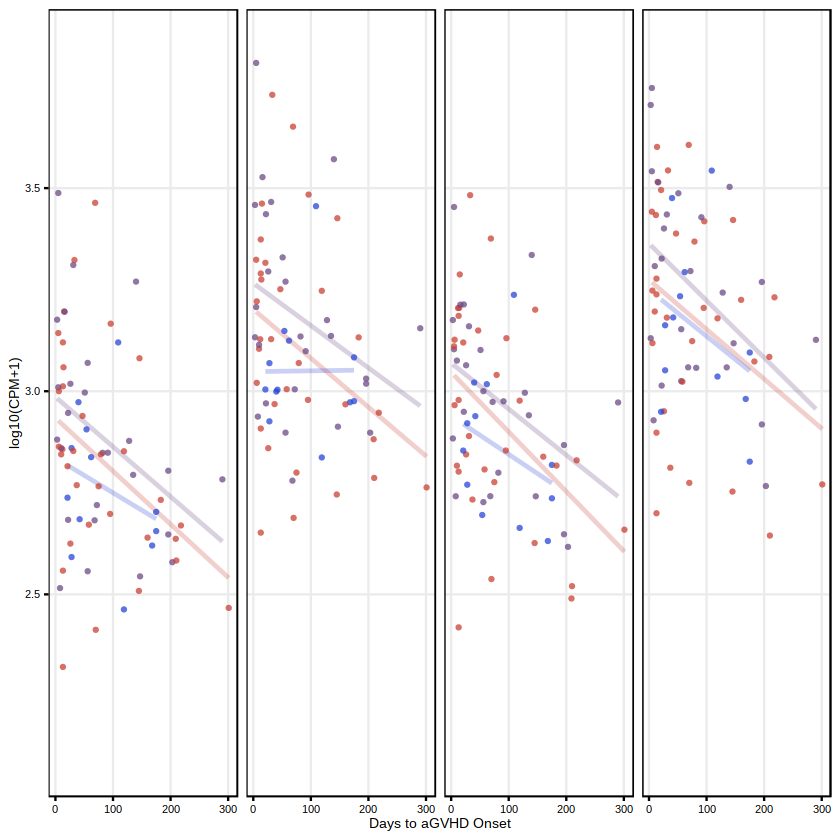

In [ ]:
COLS = c("E" = COLORs[["aGVHD+"]], "1M" = "#6B4A86", "2M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_agvhd, y=log10(counts+1), color = timepoint))+
    geom_line(stat="smooth",method = "lm",
            # color = "black",
            size = 1,alpha = 0.25)+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=1)+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "Days to aGVHD Onset")+
    scale_color_manual(values = COLS )+
    # theme(legend.position =  "right")
    theme(
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )

### Save
WIDTH = 5.1
HEIGHT = 1.5

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")